In [ ]:
# ============================================================
# AI-Based Cyber Threat Detection & Response System
# Feature Engineering Pipeline
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------
#LOAD DATASET
# ----------------------------------------------------------

# Column names for NSL-KDD dataset
COLUMNS = [
    'duration', 'protocol_type', 'service', 'flag',
    'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent',
    'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count',
    'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

def load_dataset(train_path='KDDTrain+.txt', test_path='KDDTest+.txt'):
    """Load NSL-KDD dataset from text files."""
    df_train = pd.read_csv(train_path, header=None, names=COLUMNS)
    df_test  = pd.read_csv(test_path,  header=None, names=COLUMNS)
    print(f"✅ Train shape: {df_train.shape}")
    print(f"✅ Test  shape: {df_test.shape}")
    return df_train, df_test


# ----------------------------------------------------------
# LABEL ENCODING — BINARY & MULTI-CLASS
# ----------------------------------------------------------

# Map all attack types to their category
ATTACK_MAP = {
    'normal': 'normal',
    # DoS
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS',
    'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    # Probe
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    'satan': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    # R2L
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L',
    'multihop': 'R2L', 'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L',
    'warezmaster': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',
    'snmpgetattack': 'R2L', 'snmpguess': 'R2L', 'xlock': 'R2L',
    'xsnoop': 'R2L', 'httptunnel': 'R2L',
    # U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'rootkit': 'U2R', 'ps': 'U2R', 'sqlattack': 'U2R',
    'xterm': 'U2R', 'worm': 'U2R'
}

def encode_labels(df):
    """Add binary label (0/1) and attack-category label."""
    df = df.copy()
    # Binary: 0 = normal, 1 = attack
    df['binary_label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)
    # Multi-class: normal / DoS / Probe / R2L / U2R
    df['attack_category'] = df['label'].map(ATTACK_MAP).fillna('unknown')
    print("✅ Labels encoded (binary + multi-class)")
    return df


# ----------------------------------------------------------
# CATEGORICAL ENCODING
# ----------------------------------------------------------

CATEGORICAL_COLS = ['protocol_type', 'service', 'flag']

def encode_categoricals(df_train, df_test):
    """Label-encode categorical columns using training-fit encoders."""
    encoders = {}
    for col in CATEGORICAL_COLS:
        le = LabelEncoder()
        df_train[col] = le.fit_transform(df_train[col].astype(str))
        # Handle unseen labels in test set gracefully
        df_test[col] = df_test[col].astype(str).apply(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1
        )
        encoders[col] = le
    print(f"✅ Categorical columns encoded: {CATEGORICAL_COLS}")
    return df_train, df_test, encoders


# ----------------------------------------------------------
# ENGINEERED FEATURES
# ----------------------------------------------------------

# Thresholds — tune these after EDA if needed
COUNT_THRESHOLD      = 100   # connections in 2s → high traffic
SRC_BYTES_THRESHOLD  = 50000 # bytes → large data transfer
DURATION_THRESHOLD   = 300   # seconds → long connection (5 min)

def engineer_features(df):
    """
    Create all 9 engineered features on top of direct NSL-KDD features.
    Works on both train and test DataFrames identically.
    """
    df = df.copy()

    # ----------------------------------------------------------
    # A. Traffic Intensity
    #    bytes_per_second = src_bytes / (duration + 1)
    #    High values indicate potential DoS flood
    # ----------------------------------------------------------
    df['bytes_per_second'] = df['src_bytes'] / (df['duration'] + 1)

    # ----------------------------------------------------------
    # B. Connection Ratio
    #    same_service_ratio = srv_count / (count + 1)
    #    Close to 1 = scanning same service repeatedly (Probe)
    # ----------------------------------------------------------
    df['same_service_ratio'] = df['srv_count'] / (df['count'] + 1)

    # ----------------------------------------------------------
    # C. Login Flags
    #    login_failure_flag = multiple failed logins (R2L / brute force)
    #    root_access_flag   = root shell gained (U2R)
    # ----------------------------------------------------------
    df['login_failure_flag'] = (df['num_failed_logins'] > 0).astype(int)
    df['root_access_flag']   = (df['root_shell'] == 1).astype(int)

    # ----------------------------------------------------------
    # D. High Traffic / Large Data Indicators
    #    Useful for anomaly detection module
    # ----------------------------------------------------------
    df['high_traffic_flag'] = (df['count'] > COUNT_THRESHOLD).astype(int)
    df['large_data_flag']   = (df['src_bytes'] > SRC_BYTES_THRESHOLD).astype(int)

    # ----------------------------------------------------------
    # E. Risk Indicator (used in Risk Scoring module)
    #    risk_indicator = (count x serror_rate) + src_bytes
    #    Combines volume + error signals into one score proxy
    # ----------------------------------------------------------
    df['risk_indicator'] = (df['count'] * df['serror_rate']) + df['src_bytes']

    # ----------------------------------------------------------
    # F. Error Ratio
    #    error_ratio = serror_rate + rerror_rate
    #    SYN errors + REJ errors = suspicious behavior
    # ----------------------------------------------------------
    df['error_ratio'] = df['serror_rate'] + df['rerror_rate']

    # ----------------------------------------------------------
    # G. Duration Flag
    #    long_connection_flag = unusually long sessions
    # ----------------------------------------------------------
    df['long_connection_flag'] = (df['duration'] > DURATION_THRESHOLD).astype(int)

    print("✅ All 9 engineered features created")
    return df


# ----------------------------------------------------------
# SELECT FINAL FEATURE SET
# ----------------------------------------------------------

DIRECT_FEATURES = [
    # Basic connection
    'duration', 'protocol_type', 'service', 'flag',
    # Traffic volume
    'src_bytes', 'dst_bytes',
    # Connection counts
    'count', 'srv_count',
    # Error rates
    'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    # Login / access
    'num_failed_logins', 'logged_in', 'root_shell',
]

ENGINEERED_FEATURES = [
    'bytes_per_second',
    'same_service_ratio',
    'login_failure_flag',
    'root_access_flag',
    'high_traffic_flag',
    'large_data_flag',
    'risk_indicator',
    'error_ratio',
    'long_connection_flag',
]

FINAL_FEATURES = DIRECT_FEATURES + ENGINEERED_FEATURES   # 24 features total

def select_features(df):
    """Return only the final feature columns (no labels)."""
    return df[FINAL_FEATURES]


# ----------------------------------------------------------
# SCALING (for Logistic Regression)
# ----------------------------------------------------------

def scale_features(X_train, X_test):
    """Fit StandardScaler on train, apply to both sets."""
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=FINAL_FEATURES
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        columns=FINAL_FEATURES
    )
    print("✅ Features scaled with StandardScaler")
    return X_train_scaled, X_test_scaled, scaler


# ----------------------------------------------------------
# MASTER PIPELINE
# ----------------------------------------------------------

def run_pipeline(train_path='KDDTrain+.txt', test_path='KDDTest+.txt'):
    """
    End-to-end feature engineering pipeline.

    Returns:
        X_train_scaled, X_test_scaled  -- model input (scaled)
        y_train, y_test                -- binary labels
        y_train_mc, y_test_mc          -- multi-class labels
        scaler, encoders               -- save these for inference
        df_train, df_test              -- full engineered DataFrames
    """
    print("\n" + "="*55)
    print("  NSL-KDD Feature Engineering Pipeline")
    print("="*55)

    # 1. Load
    df_train, df_test = load_dataset(train_path, test_path)

    # 2. Label encode
    df_train = encode_labels(df_train)
    df_test  = encode_labels(df_test)

    # 3. Categorical encode
    df_train, df_test, encoders = encode_categoricals(df_train, df_test)

    # 4. Feature engineering
    df_train = engineer_features(df_train)
    df_test  = engineer_features(df_test)

    # 5. Select features & labels
    X_train = select_features(df_train)
    X_test  = select_features(df_test)
    y_train    = df_train['binary_label']
    y_test     = df_test['binary_label']
    y_train_mc = df_train['attack_category']
    y_test_mc  = df_test['attack_category']

    # 6. Scale
    X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

    # Summary
    print(f"\n📊 Final feature count : {len(FINAL_FEATURES)}")
    print(f"   Direct features     : {len(DIRECT_FEATURES)}")
    print(f"   Engineered features : {len(ENGINEERED_FEATURES)}")
    print(f"\n📦 X_train shape: {X_train_scaled.shape}")
    print(f"📦 X_test  shape: {X_test_scaled.shape}")
    print(f"\n🏷  Binary class dist (train):\n{y_train.value_counts().to_string()}")
    print(f"\n🏷  Attack categories (train):\n{y_train_mc.value_counts().to_string()}")
    print("\n✅ Pipeline complete — ready for ML training!\n")

    return (
        X_train_scaled, X_test_scaled,
        y_train, y_test,
        y_train_mc, y_test_mc,
        scaler, encoders,
        df_train, df_test
    )

if __name__ == '__main__':
    # With real dataset files:
    run_pipeline('KDDTrain+.txt', 'KDDTest+.txt')


  NSL-KDD Feature Engineering Pipeline
✅ Train shape: (125973, 43)
✅ Test  shape: (22544, 43)
✅ Labels encoded (binary + multi-class)
✅ Labels encoded (binary + multi-class)
✅ Categorical columns encoded: ['protocol_type', 'service', 'flag']
✅ All 9 engineered features created
✅ All 9 engineered features created
✅ Features scaled with StandardScaler

📊 Final feature count : 24
   Direct features     : 15
   Engineered features : 9

📦 X_train shape: (125973, 24)
📦 X_test  shape: (22544, 24)

🏷  Binary class dist (train):
binary_label
0    67343
1    58630

🏷  Attack categories (train):
attack_category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52

✅ Pipeline complete — ready for ML training!



In [6]:
# Run pipeline
X_train, X_test, y_train, y_test, _, _, scaler, encoders, _, _ = run_pipeline()


  NSL-KDD Feature Engineering Pipeline
✅ Train shape: (125973, 43)
✅ Test  shape: (22544, 43)
✅ Labels encoded (binary + multi-class)
✅ Labels encoded (binary + multi-class)
✅ Categorical columns encoded: ['protocol_type', 'service', 'flag']
✅ All 9 engineered features created
✅ All 9 engineered features created
✅ Features scaled with StandardScaler

📊 Final feature count : 24
   Direct features     : 15
   Engineered features : 9

📦 X_train shape: (125973, 24)
📦 X_test  shape: (22544, 24)

🏷  Binary class dist (train):
binary_label
0    67343
1    58630

🏷  Attack categories (train):
attack_category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52

✅ Pipeline complete — ready for ML training!



In [7]:

# Train Model
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1
)
model.fit(X_train, y_train)

print(X_train.head())

   duration  protocol_type   service      flag  src_bytes  dst_bytes  \
0 -0.110249      -0.124706 -0.686785  0.751111  -0.007679  -0.004919   
1 -0.110249       2.219312  0.781428  0.751111  -0.007737  -0.004919   
2 -0.110249      -0.124706  1.087305 -0.736235  -0.007762  -0.004919   
3 -0.110249      -0.124706 -0.442083  0.751111  -0.007723  -0.002891   
4 -0.110249      -0.124706 -0.442083  0.751111  -0.007728  -0.004814   

      count  srv_count  serror_rate  srv_serror_rate  ...  root_shell  \
0 -0.717045  -0.354343    -0.637209        -0.631929  ...   -0.036652   
1 -0.620982  -0.368110    -0.637209        -0.631929  ...   -0.036652   
2  0.339648  -0.299273     1.602664         1.605104  ...   -0.036652   
3 -0.690846  -0.313041    -0.189235        -0.184522  ...   -0.036652   
4 -0.472521   0.058678    -0.637209        -0.631929  ...   -0.036652   

   bytes_per_second  same_service_ratio  login_failure_flag  root_access_flag  \
0         -0.006042           -0.144415        

In [8]:
from sklearn.metrics import classification_report
# Evaluate model 
y_probs = model.predict_proba(X_test)[:,1]

y_pred = (y_probs > 0.06).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93      9711
           1       0.97      0.93      0.95     12833

    accuracy                           0.94     22544
   macro avg       0.94      0.94      0.94     22544
weighted avg       0.94      0.94      0.94     22544



In [9]:
# confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("confusion matrix -> ")
print(cm)

confusion matrix -> 
[[ 9309   402]
 [  921 11912]]


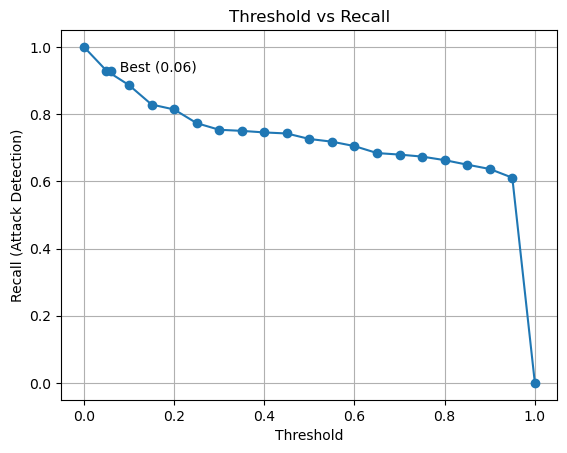

In [10]:
# Recall vs Threshold comparision
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score

# Get prediction probabilities
y_probs = model.predict_proba(X_test)[:, 1]

# Define thresholds
thresholds = np.arange(0.0, 1.01, 0.05)

recalls = []

# Calculate recall for each threshold
for t in thresholds:
    y_pred = (y_probs > t).astype(int)
    recall = recall_score(y_test, y_pred)
    recalls.append(recall)

# Plot
plt.figure()
plt.plot(thresholds, recalls, marker='o')

plt.xlabel("Threshold")
plt.ylabel("Recall (Attack Detection)")
plt.title("Threshold vs Recall")

plt.grid()

best_threshold = 0.06
best_recall = recall_score(y_test, (y_probs > best_threshold).astype(int))

plt.scatter(best_threshold, best_recall)
plt.text(best_threshold, best_recall, f"  Best (0.06)", fontsize=10)

plt.show()

In [11]:
import joblib

joblib.dump(model,    'model.pkl')
joblib.dump(scaler,   'scaler.pkl')
joblib.dump(encoders, 'encoders.pkl')

print("✅ model.pkl saved")
print("✅ scaler.pkl saved")
print("✅ encoders.pkl saved")

✅ model.pkl saved
✅ scaler.pkl saved
✅ encoders.pkl saved
